In [42]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# a raiz do projeto e a pasta pai de Tests/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Tests" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

with open(PROJECT_ROOT / "Params" / "paths.json", "r") as f:
    paths = json.load(f)
with open(PROJECT_ROOT / "Params" / "stocks.json", "r") as f:
    stocks_cfg = json.load(f)

from Utils.extraction_module import StockDataWarehouse, StockDataFetcher 
from Utils.financial_module import StockPortfolio, PortfolioVariance, SharpeIndex, VaR, CVaR, STARRIndex, ReturnSampler
from Utils.doe_module import Sobol, LHS, SamplerShell, Map2Simplex
from Utils.plot_module import (
    StockTimeSeriesPlotter,
    plot_doe_3d,
    plot_doe_comparison_3d,
    plot_metric_3d,
    plot_metric_comparison_3d,
    plot_gp_prior_comparison,
    plot_simplex_slices_2d,
    plot_surrogate_surface_3d_interactive,
    plot_surrogate_comparison_3d,
    plot_efficient_frontier,
    plot_optimal_compositions,
)
from Utils.surrogate_module import SurrogateKernels, SurrogateGPR
from Utils.optim_module import EFOptimizer

%matplotlib inline

SEED = 42
N_DOE_DEMO = 128  # power of 2 avoids scipy Sobol balance-property warning (sobol works best in powers of 2 to cover space more equally)
RF = (1 + 0.04)**(1/252) - 1 # daily safe rate for STARR Index and Sharpe Index (represents safe expecte returns on alternative investment)
N_FILLER = 2**12 # number of points to examplify method that explores predictor quickness to use optimization by trial on the surrogate model

In [2]:
sdf = StockDataFetcher(
    start_date=stocks_cfg["start_date"],
    end_date=stocks_cfg["end_date"],
    interval=stocks_cfg["interval"],
)

sdw = StockDataWarehouse(sdf)

stocks_status = sdw.add_stocks(stocks_cfg["tickers"], auto_adjust=stocks_cfg["auto_adjust"])
if stocks_status:
    raise Exception(f"Failed to obtain data: {stocks_status}")

print(sdw.list_stocks())
print(f"{sdf.start_date} - {sdf.end_date}")

price_panel = sdw.price_panel()

price_panel.head()

['MSFT', 'JPM', 'PG']
2010-01-01 - 2026-01-01


,MSFT,JPM,PG
Date,,,
2010-01-04,23.027504,28.152374,37.580551
2010-01-05,23.034945,28.697691,37.592857
2010-01-06,22.893585,28.855364,37.414547
2010-01-07,22.655500,29.426962,37.211636
2010-01-08,22.811737,29.354691,37.162441


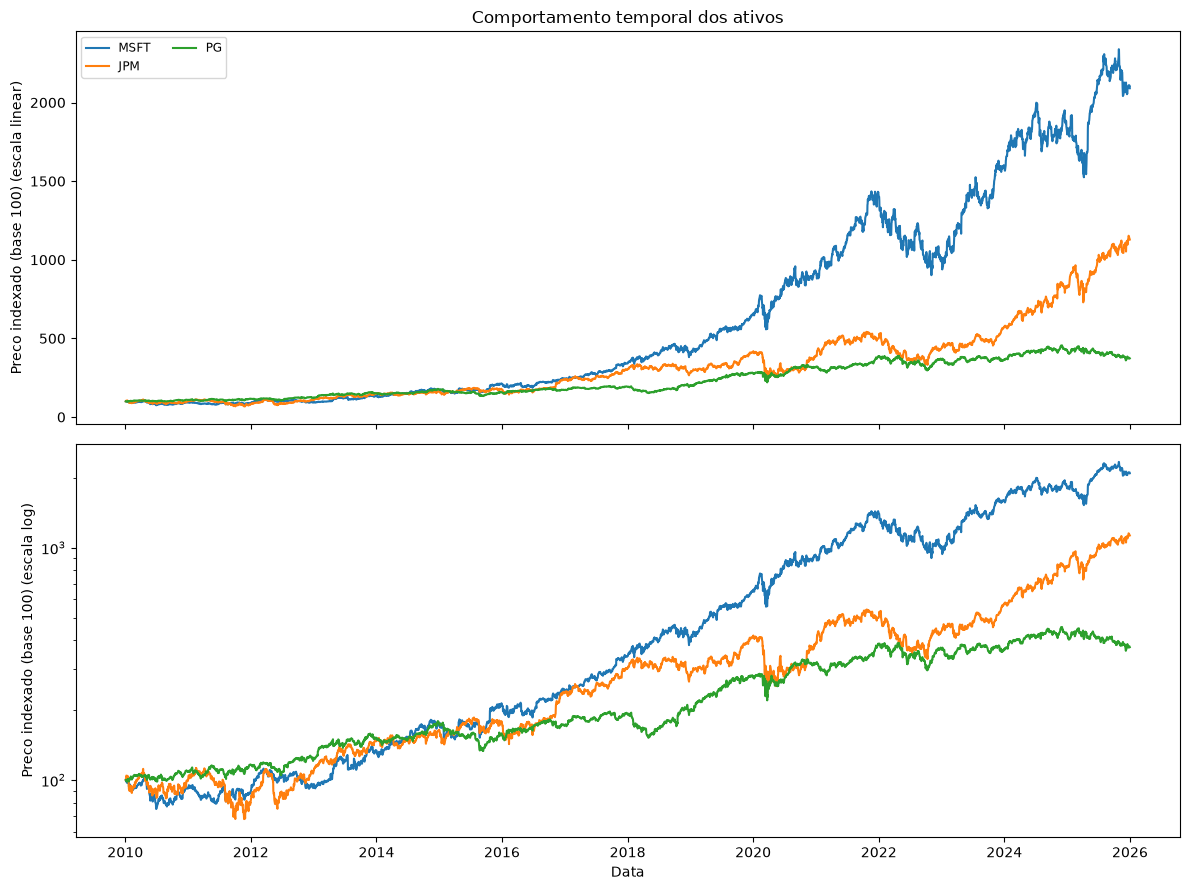

In [3]:
sts_plotter = StockTimeSeriesPlotter(sdw)
price_series_fig = sts_plotter.plot_price_series(normalize=True, log_scale=True)
plt.show()

In [4]:
np.asarray(sorted(price_panel["PG"]))

array([ 37.01486588,  37.03089905,  37.0558548 , ..., 170.89082336,
       170.93849182, 171.26252747], shape=(4024,))

In [5]:
sobol_shell = SamplerShell(sampler_cls=Sobol,
                           dim=3,
                           mapper_cls=Map2Simplex,
                           sampler_kwargs={"seed": SEED})

lhs_shell = SamplerShell(sampler_cls=LHS,
                         dim=3,
                         mapper_cls=Map2Simplex,
                         sampler_kwargs={"seed": SEED})

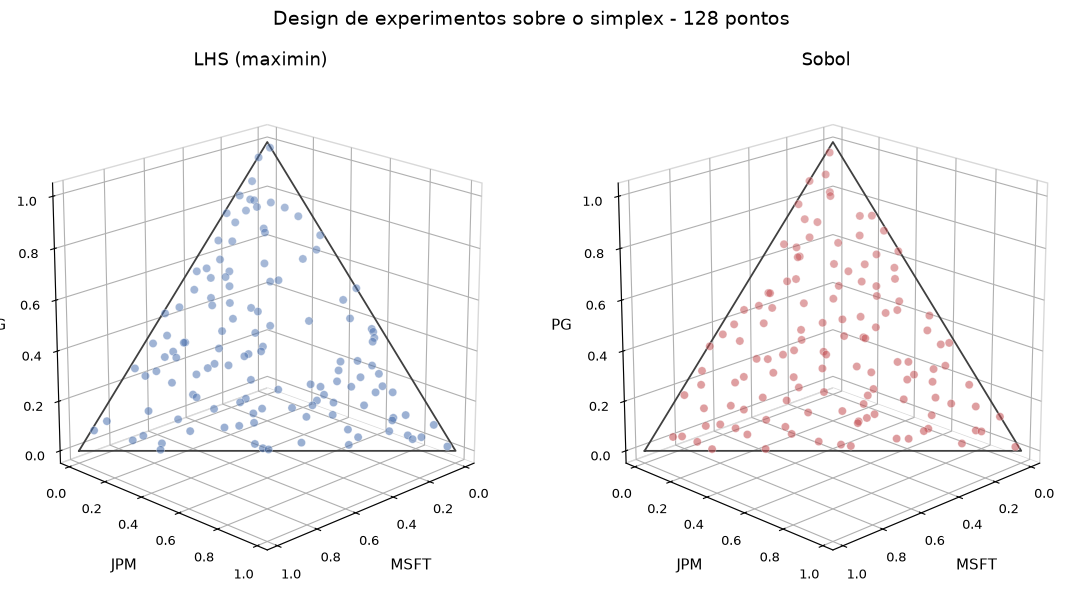

In [6]:
sobol_doe = sobol_shell(N_DOE_DEMO)
lhs_doe = lhs_shell(N_DOE_DEMO)

doe_fig = plot_doe_comparison_3d(
    {"LHS (maximin)": lhs_doe, "Sobol": sobol_doe},
    labels=sdw.list_stocks(),
    suptitle=f"Design de experimentos sobre o simplex - {N_DOE_DEMO} pontos",
)

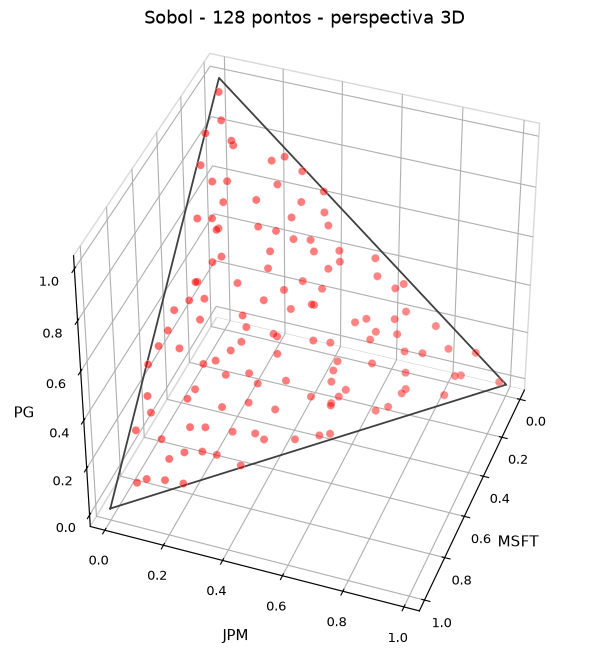

In [7]:
sobol_low_angle_fig, _ = plot_doe_3d(
    sobol_doe,
    labels=sdw.list_stocks(),
    title=f"Sobol - {N_DOE_DEMO} pontos - perspectiva 3D",
    elev=40,
    azim=20,
    color="red"
)

(4023, 3)
(128, 3)
(128, 4023)


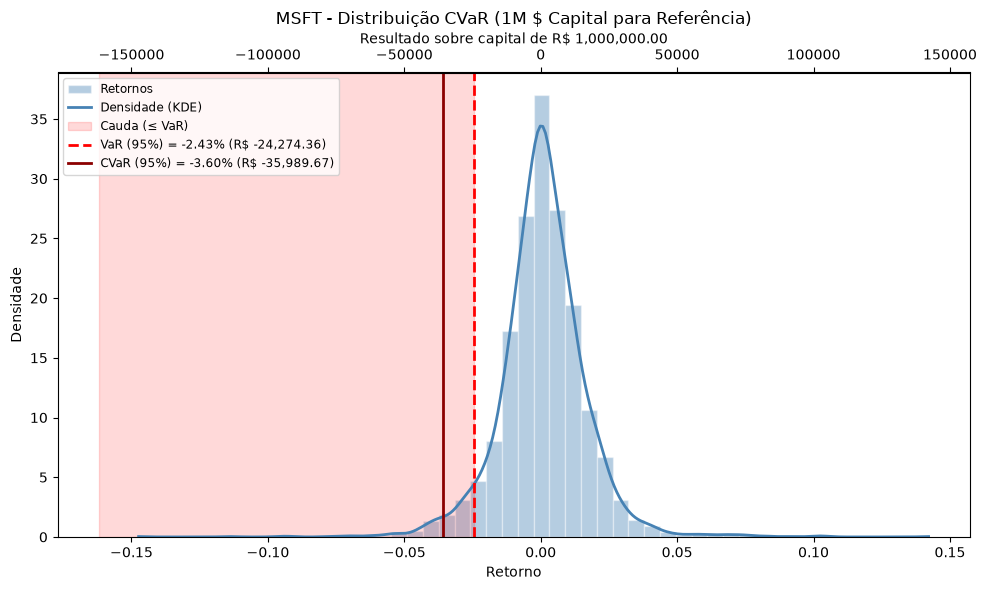

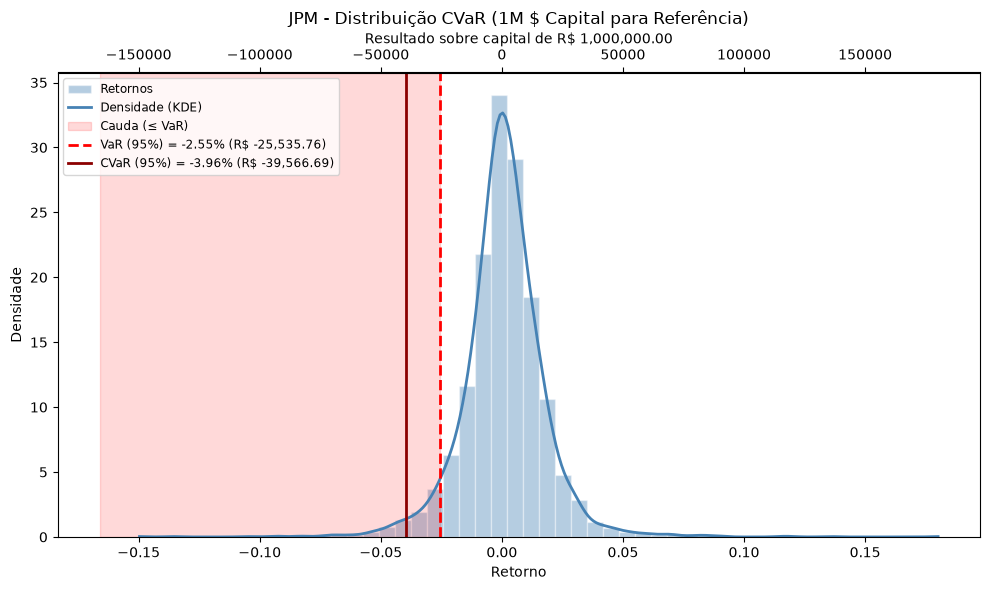

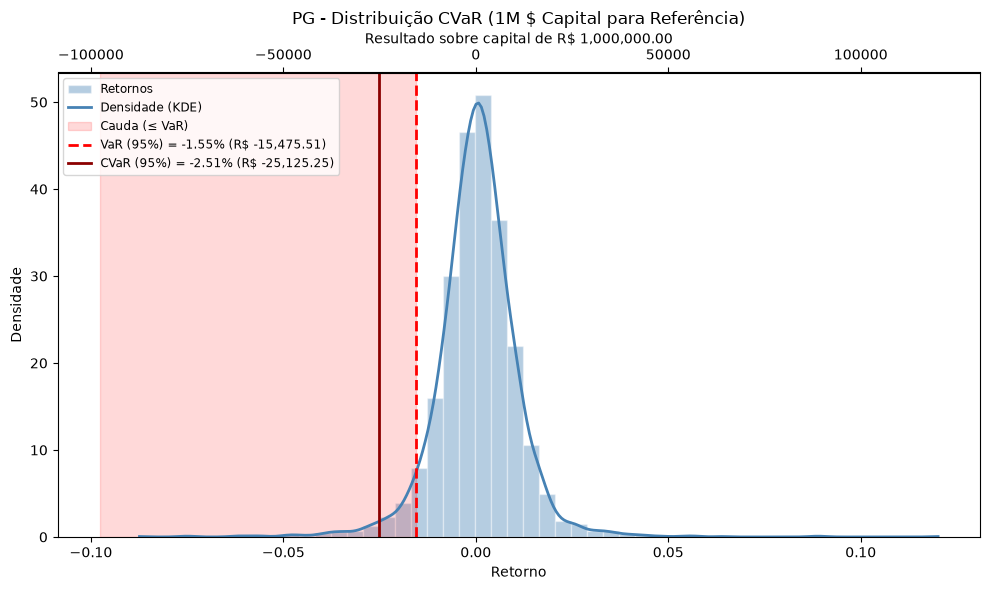

In [31]:
ret_sampler = ReturnSampler() # simple return sampler for historic sampling over full extracted timeseries day-by-day

rets = ret_sampler(price_panel)

print(rets.shape)

print(sobol_doe.shape)


ret_dot_sobol = sobol_doe @ rets.T

print(ret_dot_sobol.shape)

#individual CVaR for plot for single asset portfolios for later comparative analysis
cvar1asset = CVaR(n_assets=1, alpha=0.95, type="non-parametric")

cvar1asset = CVaR(n_assets=1, alpha=0.95, type="non-parametric")
for i, tkr in enumerate(price_panel.columns):
    cvar1asset.plotDistribution(rets[:, i], title=f"{tkr} - Distribuição CVaR (1M $ Capital para Referência)", bins=50, capital=1000000)


In [34]:
#CVaR

from time import time

cvar = CVaR(n_assets=3, alpha=0.95, type="non-parametric")

start_time = time()
cvar_sobol = np.array([cvar(ret_)[0] for ret_ in ret_dot_sobol])
end_time = time()

print(cvar_sobol.shape)

print(f"Time taken to compute CVaR for {N_DOE_DEMO} Sobol points: {end_time - start_time:.4f} seconds")


(128,)
Time taken to compute CVaR for 128 Sobol points: 0.0334 seconds


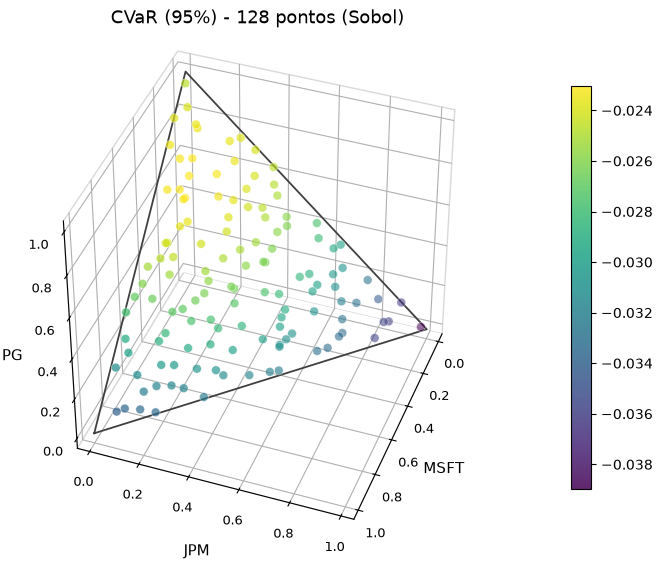

In [10]:
metric_fig = plot_metric_3d(
    sobol_doe,
    cvar_sobol,
    labels = sdw.list_stocks(),
    title=f"CVaR (95%) - {N_DOE_DEMO} pontos (Sobol)",
    elev=40,
    azim=20,
)

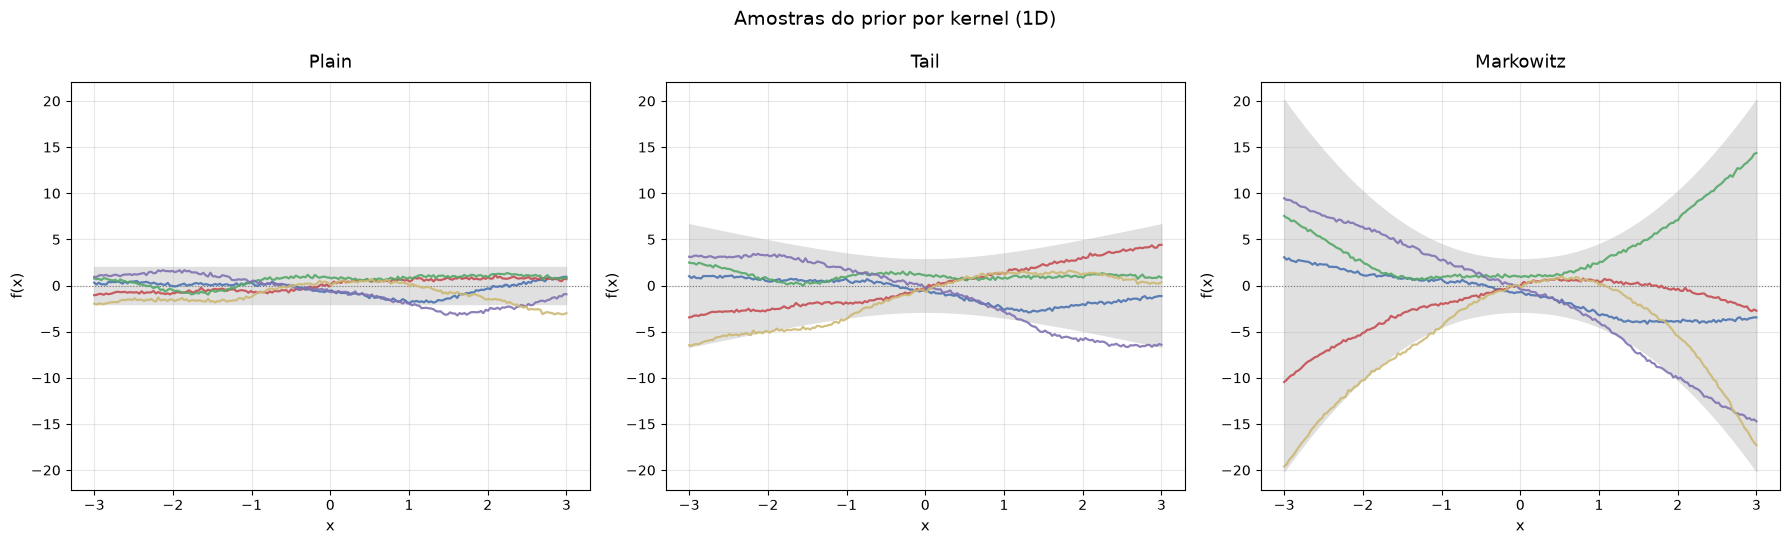

In [11]:
kernel_plain_1d = SurrogateKernels.Plain(n_dims=1).build()
kernel_tail_1d = SurrogateKernels.Tail(n_dims=1).build()
kernel_markowitz_1d = SurrogateKernels.Markowitz(n_dims=1).build()

gp_prior_1d_fig = plot_gp_prior_comparison(
    {"Plain": kernel_plain_1d, "Tail": kernel_tail_1d, "Markowitz": kernel_markowitz_1d},
    n_dims=1,
    suptitle="Amostras do prior por kernel (1D)",
    seed=SEED
)

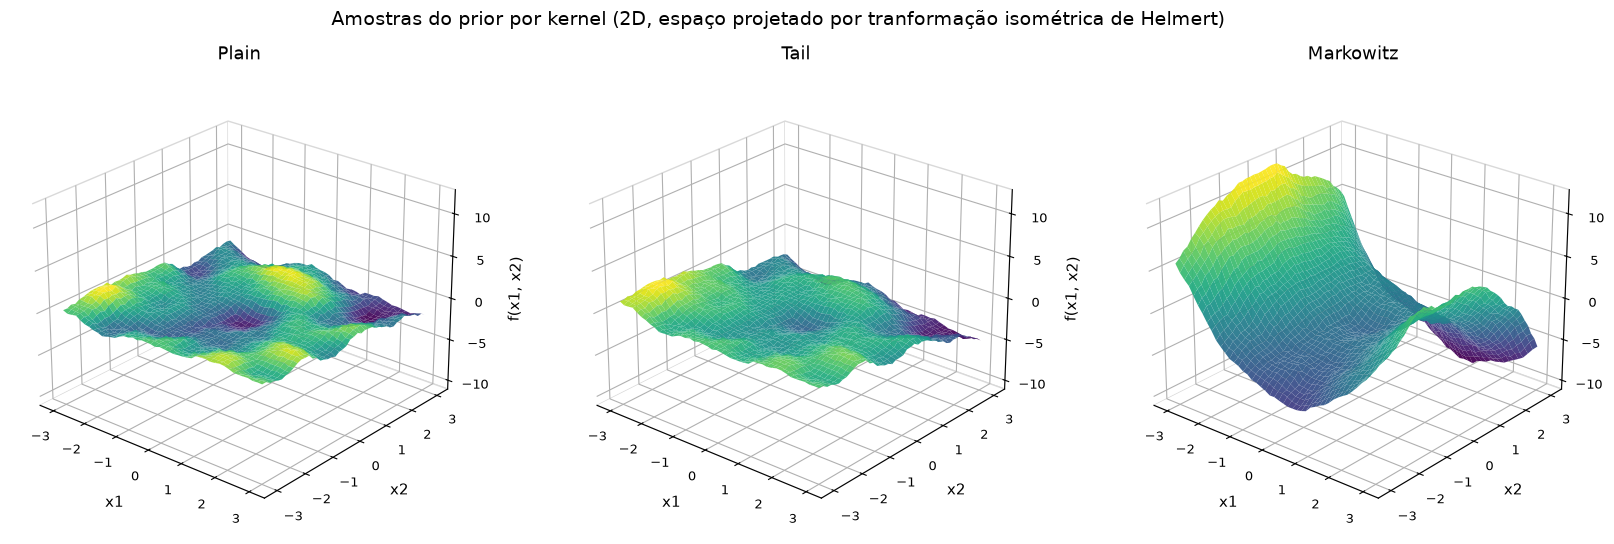

In [12]:
kernel_plain_2d = SurrogateKernels.Plain(n_dims=2).build()
kernel_tail_2d = SurrogateKernels.Tail(n_dims=2).build()
kernel_markowitz_2d = SurrogateKernels.Markowitz(n_dims=2).build()

gp_prior_2d_fig = plot_gp_prior_comparison(
    {"Plain": kernel_plain_2d, "Tail": kernel_tail_2d, "Markowitz": kernel_markowitz_2d},
    n_dims=2,
    suptitle="Amostras do prior por kernel (2D, espaço projetado por tranformação isométrica de Helmert)",
    seed=SEED
)

In [13]:
plain_kernel = SurrogateKernels.Plain(n_dims=2)
tail_kernel = SurrogateKernels.Tail(n_dims=2)
mark_kernel = SurrogateKernels.Markowitz(n_dims=2)

cvarGPR = SurrogateGPR(mark_kernel, n_assets=3, n_restarts=10, sim_obj="cvar", random_state=SEED)
cvarGPR.fit(W=sobol_doe, y=cvar_sobol)
print("fitted kernel:", cvarGPR.kernel_)
print()
for key, value in cvarGPR.diagnostics().items():
    print(f"{key}: {value}")

fitted kernel: 2.69**2 * Matern(length_scale=[2.22, 2.29], nu=2.5) + DotProduct(sigma_0=0.00112) ** 2 + WhiteKernel(noise_level=8.4e-07)

length_scales: [2.22309707 2.2890856 ]
n_scale_terms: 1
amplitude: 7.241027993869362
noise: 8.40425676703371e-07
snr: 8615905.242534718
log_marg_like: 505.86790211283295


In [14]:
surface_fig = plot_surrogate_surface_3d_interactive(
    lambda W: cvarGPR.predict(W, return_std=False),
    labels=sdw.list_stocks(),
    train_points=sobol_doe,
    train_values=cvar_sobol,
    title="Markowitz - superficie ajustada do CVaR",
    zlabel="CVaR",
)
surface_fig.show()

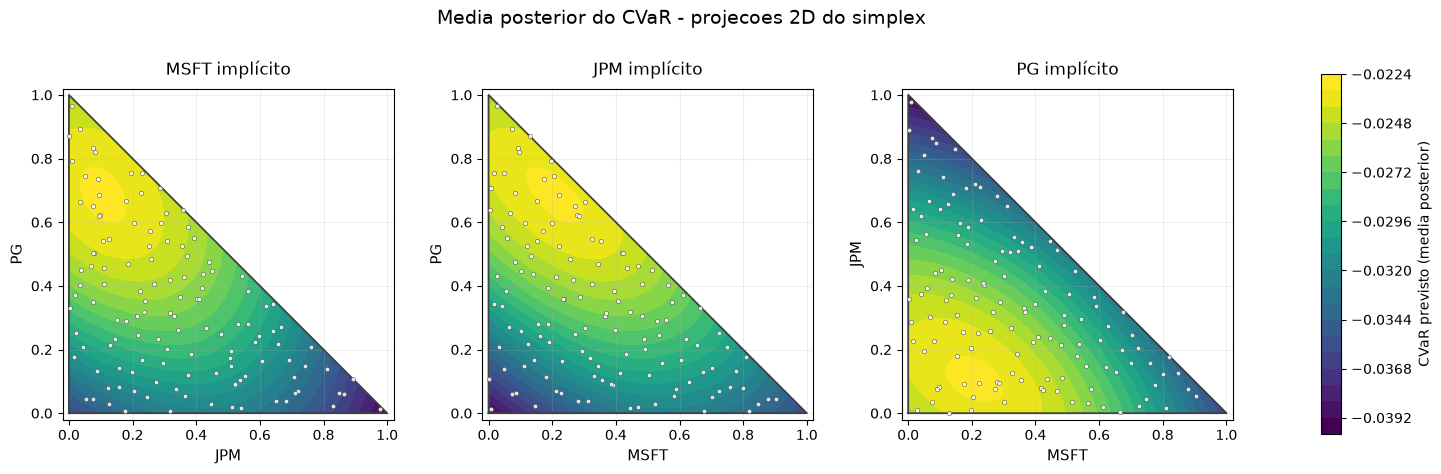

In [15]:
slices_mean_fig = plot_simplex_slices_2d(
    lambda W: cvarGPR.predict(W, return_std=True)[0],
    labels=sdw.list_stocks(),
    overlay_points=sobol_doe,
    colorbar_label="CVaR previsto (media posterior)",
    suptitle="Media posterior do CVaR - projecoes 2D do simplex",
)

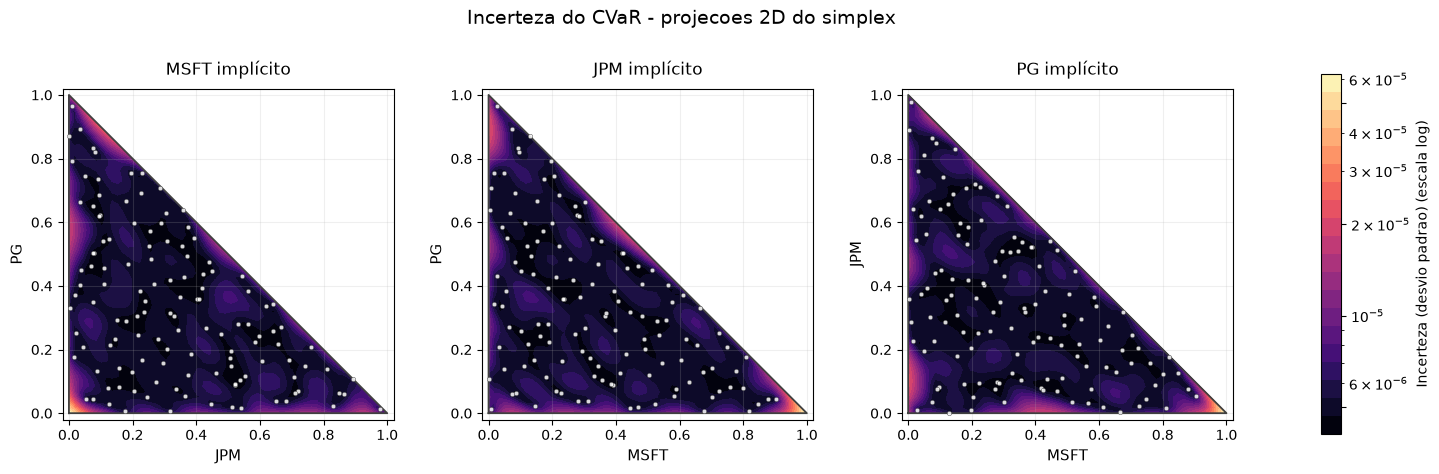

In [16]:
slices_std_fig = plot_simplex_slices_2d(
    lambda W: cvarGPR.predict(W, return_std=True)[1],
    labels=sdw.list_stocks(),
    overlay_points=sobol_doe,
    colorbar_label="Incerteza (desvio padrao)",
    cmap="magma",
    log_scale=True,
    suptitle="Incerteza do CVaR - projecoes 2D do simplex",
)

In [17]:
mu = np.asarray(rets.mean(axis=0))  # historical mean daily return per asset
print("Expected returns (mu):", dict(zip(sdw.list_stocks(), mu)))

ef_optimizer = EFOptimizer(surrogate=cvarGPR, kernel_cls=cvarGPR.kernel_obj, higher_is_better=True, n_restarts=10)
# higher_is_better=True: this project's CVaR is a signed tail return (see Utils/financial_module.py),
# so a less negative value is the safer one, not a smaller raw value.

G_grid = np.linspace(mu.min() * 1.6, mu.max() * 0.98, 10)  # We dont want to go close to the minimum because it colapses many solutions into the same point
# the colapse happens because very low risk wallets can still reach the smaller solutions and thus the optimizer will return many similar solutions for different G values close to the minimum, which is not useful for the efficient frontier plot
print("G_grid:", G_grid)

tol = (mu.max()-mu.min())*1e-3  # tolerance for G values to avoid numerical issues

ineq_results = [
    ef_optimizer.optimize(
        mu=mu, G=G, mode="ineq",
        eta=0.3, rho0=10.0, rho_growth=1.5, rho_max=1e6,
        n_inner=300, n_outer=60,
        tol_feas=tol, random_state=SEED, verbose=1
    )
    for G in G_grid
]

Expected returns (mu): {'MSFT': np.float64(0.0008847987171179589), 'JPM': np.float64(0.0007534547838271432), 'PG': np.float64(0.0003860349602604055)}
G_grid: [0.00061766 0.00064537 0.00067309 0.0007008  0.00072852 0.00075624
 0.00078395 0.00081167 0.00083939 0.0008671 ]


EFOptimizer restarts:  10%|█         | 1/10 [00:08<01:17,  8.58s/it, best_R=0.0006, best_cost=-0.0239, best_feasible=True]

[restart 1/10] R=0.0006 target(G)=0.0006 R-G=-0.0000 surface=-0.0239 lam=20.7 rho=8.52e+05 viol=1.83e-07 feasible=True


EFOptimizer restarts:  20%|██        | 2/10 [00:17<01:08,  8.62s/it, best_R=0.0006, best_cost=-0.0239, best_feasible=True]

[restart 2/10] R=0.0006 target(G)=0.0006 R-G=-0.0000 surface=-0.0239 lam=20.7 rho=8.52e+05 viol=1.83e-07 feasible=True


...

[restart 8/10] R=0.0009 target(G)=0.0009 R-G=-0.0000 surface=-0.0341 lam=86.1 rho=1e+06 viol=4.75e-07 feasible=True


EFOptimizer restarts:  90%|█████████ | 9/10 [01:19<00:08,  8.41s/it, best_R=0.0009, best_cost=-0.0341, best_feasible=True]

[restart 9/10] R=0.0009 target(G)=0.0009 R-G=-0.0000 surface=-0.0341 lam=86.1 rho=1e+06 viol=4.75e-07 feasible=True


EFOptimizer restarts: 100%|██████████| 10/10 [01:29<00:00,  8.93s/it, best_R=0.0009, best_cost=-0.0341, best_feasible=True]

[restart 10/10] R=0.0009 target(G)=0.0009 R-G=-0.0000 surface=-0.0341 lam=86.1 rho=1e+06 viol=4.75e-07 feasible=True
==> selected: R=0.0009 target(G)=0.0009 R-G=-0.0000 risk_mean=-0.0341 risk_std=0.0000 feasible=True violation=4.75e-07


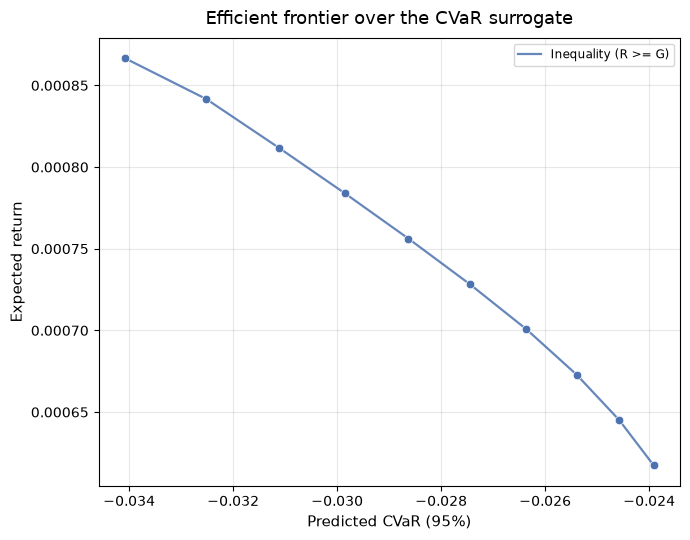

In [18]:
frontiers = {
    "Inequality (R >= G)": {
        "risk": np.array([r["risk_mean"] for r in ineq_results]),
        "return": np.array([r["R"] for r in ineq_results]),
        "feasible": np.array([r["feasible"] for r in ineq_results]),
    }}

frontier_fig, frontier_ax = plot_efficient_frontier(
    frontiers,
    risk_label="Predicted CVaR (95%)",
    title="Efficient frontier over the CVaR surrogate",
)
plt.show()

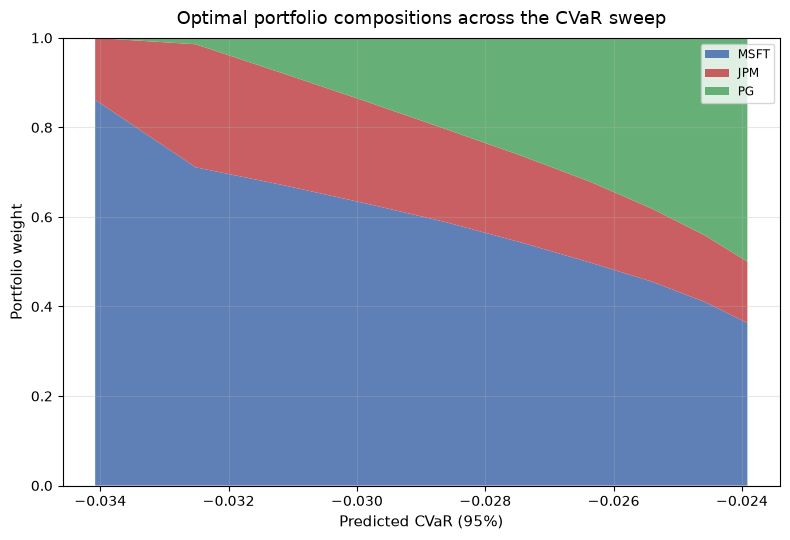

In [19]:
weights_ineq = np.stack([r["w_star"] for r in ineq_results])
risk_ineq = np.array([r["risk_mean"] for r in ineq_results])

compositions_fig, compositions_ax = plot_optimal_compositions(
    risk_ineq,
    weights_ineq,
    asset_labels=sdw.list_stocks(),
    risk_label="Predicted CVaR (95%)",
    title="Optimal portfolio compositions across the CVaR sweep",
)
plt.show()

(4096, 3)


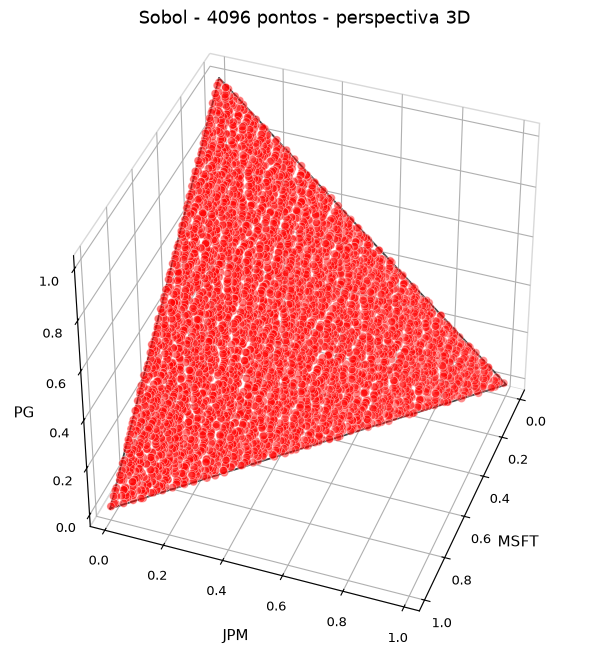

In [43]:
sobol_shell_filler = SamplerShell(sampler_cls=Sobol,
                           dim=3,
                           mapper_cls=Map2Simplex,
                           sampler_kwargs={"seed": SEED})

sobol_filler = sobol_shell_filler(N_FILLER)

print(sobol_filler.shape)

sobol_low_angle_fig, _ = plot_doe_3d(
    sobol_filler,
    labels=sdw.list_stocks(),
    title=f"Sobol - {N_FILLER} pontos - perspectiva 3D",
    elev=40,
    azim=20,
    color="red"
)




In [60]:
start_time_pred = time()
cvarGPR_predictions, cvarGPR_std = cvarGPR.predict(sobol_filler, return_std=True)
end_time_pred = time()

print(f"Time taken to predict CVaR for {N_FILLER} Sobol filler points: {end_time_pred - start_time_pred:.4f} seconds")
print(f"Shape of CVaR predictions: {cvarGPR_predictions.shape}")
print(f"Shape of CVaR standard deviations: {cvarGPR_std.shape}")

Time taken to predict CVaR for 4096 Sobol filler points: 0.0664 seconds
Shape of CVaR predictions: (4096,)
Shape of CVaR standard deviations: (4096,)


In [65]:
ret_filler = ReturnSampler() # simple return sampler for historic sampling over full extracted timeseries day-by-day

rets_for_filler = ret_filler(price_panel)

print(rets_for_filler.shape)

ret_dot_sobol_filler = sobol_filler @ rets_for_filler.T

print(ret_dot_sobol_filler.shape)

mu_filler = np.asarray(ret_dot_sobol_filler.mean(axis=1))  # historical mean daily return per asset
print(f"Shape of mean returns: {mu_filler.shape}")


(4023, 3)
(4096, 4023)
Shape of mean returns: (4096,)


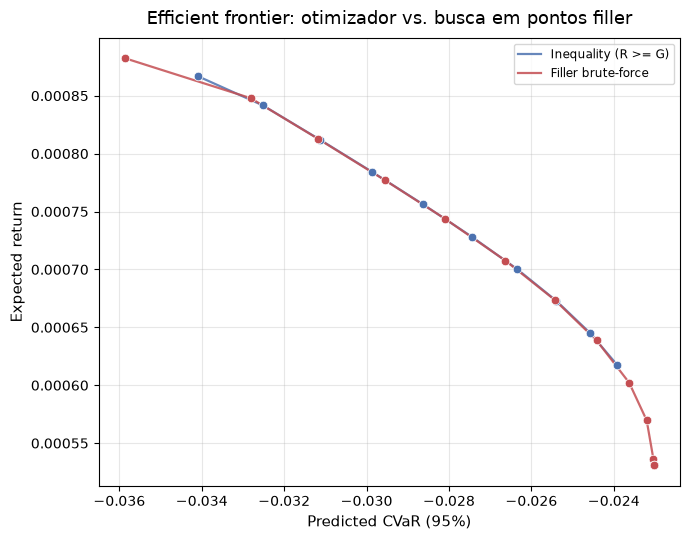

In [76]:
# Fronteira eficiente "por força bruta" sobre os pontos filler (sem otimizador, só indexação)

G_grid_filler = np.linspace(mu_filler.min(), mu_filler.max(), 15)

risk_filler = []
return_filler = []
weights_filler = []

for G in G_grid_filler:
    mask = mu_filler >= G  # condição 1: retorno >= G
    # condição 2: menor risco possível entre os que satisfazem a condição 1
    # (CVaR aqui é sinalizado e higher_is_better=True, então "menor risco" = maior valor de CVaR)
    idx = np.where(mask)[0][np.argmax(cvarGPR_predictions[mask])]

    risk_filler.append(cvarGPR_predictions[idx])
    return_filler.append(mu_filler[idx])
    weights_filler.append(sobol_filler[idx])

risk_filler = np.array(risk_filler)
return_filler = np.array(return_filler)
weights_filler = np.array(weights_filler)

frontiers["Filler brute-force"] = {
    "risk": risk_filler,
    "return": return_filler,
    "feasible": np.ones_like(return_filler, dtype=bool),
}

frontier_fig, frontier_ax = plot_efficient_frontier(
    frontiers,
    risk_label="Predicted CVaR (95%)",
    title="Efficient frontier: otimizador vs. busca em pontos filler",
)
plt.show()


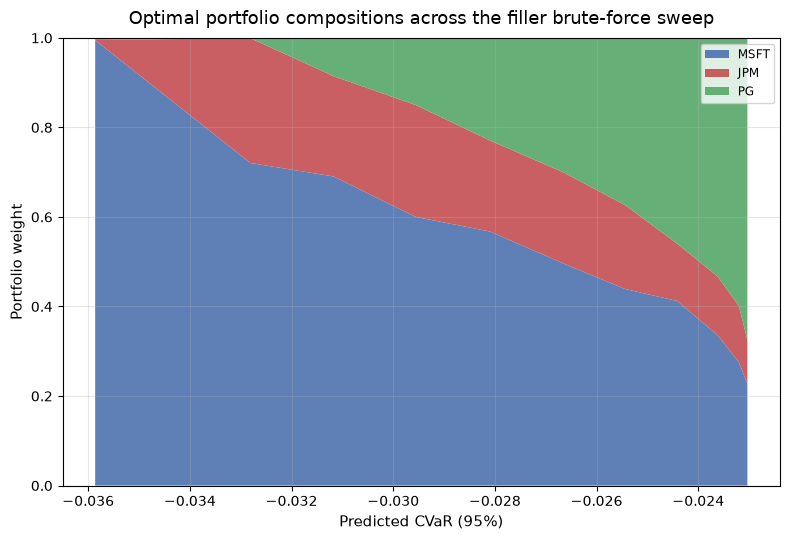

In [77]:
compositions_filler_fig, compositions_filler_ax = plot_optimal_compositions(
    risk_filler,
    weights_filler,
    asset_labels=sdw.list_stocks(),
    risk_label="Predicted CVaR (95%)",
    title="Optimal portfolio compositions across the filler brute-force sweep",
)
plt.show()
